Works out the SST distrubution of photozoan T factories

In [1]:
import pandas as pd
import xarray as xr

OMP: Warning #179: Function Can't set size of /tmp file failed:


In [2]:
photozoan_locs = '../data/photozoan_locations/photozoan_filtered.csv'
sst_data = '../data/sst.mon.ltm.1981-2010.nc'

/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xarray/coding/times.py:992: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/jono/opt/anaconda3/envs/paleoReef/lib/python3.12/site-packages/xarray/core/indexing.py:526: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(self.get_duck_array(), dtype=dtype)


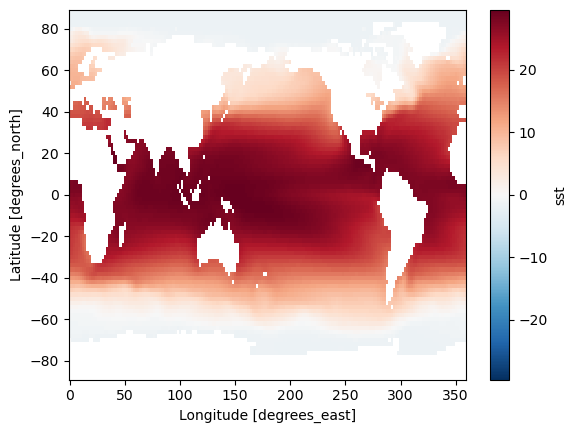

In [3]:
sst = xr.open_dataset(sst_data)
# sst['sst'][0].plot()
# get average of all time grids
sst_mean = sst['sst'].mean(dim='time')
sst_mean.plot()

In [4]:
coral_locs = pd.read_csv(photozoan_locs)
# covert lons to 0-360
coral_locs['lon'] = coral_locs['lon'] % 360

In [5]:
# sample average SST 
for index, row in coral_locs.iterrows():
    lon = row['lon']
    lat = row['lat']
    sst_value = sst_mean.sel(lon=lon, lat=lat, method="nearest")

    if lat > 0:
        sst_warm_month = sst['sst'][6]
        sst_cool_month = sst['sst'][0]
    else:
        sst_warm_month = sst['sst'][0]
        sst_cool_month = sst['sst'][6]
    sst_warm_month = sst_warm_month.sel(lon=lon, lat=lat, method="nearest")
    sst_cool_month = sst_cool_month.sel(lon=lon, lat=lat, method="nearest")

    coral_locs.at[index, 'sst'] = sst_value.values
    coral_locs.at[index, 'sst_warm_month'] = sst_warm_month.values
    coral_locs.at[index, 'sst_cool_month'] = sst_cool_month.values

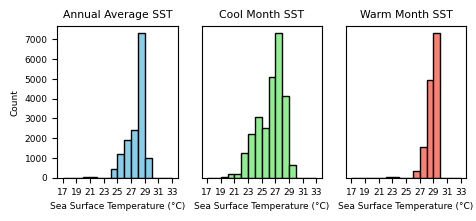

In [6]:
# Three histograms of annual average sst, cool and warm month ssts
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 6.5})
mm = 1/25.4  # mm in inches
fig,axs = plt.subplots(1,3,figsize=(134*mm,50*mm))
axs[0].hist(coral_locs['sst'], bins=range(17, 34), color='skyblue', edgecolor='black')
axs[0].set_title('Annual Average SST')
axs[0].set_xlabel('Sea Surface Temperature (°C)')
axs[0].set_xticks(range(17, 34, 2))
axs[0].set_ylabel('Count')
axs[1].hist(coral_locs['sst_cool_month'], bins=range(17, 34), color='lightgreen', edgecolor='black')
axs[1].set_title('Cool Month SST')
axs[1].set_xlabel('Sea Surface Temperature (°C)')
# axs[1].set_ylabel('Frequency')
# hide y_ticks
axs[1].tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelright=False)
axs[1].set_xticks(range(17, 34, 2))
axs[2].hist(coral_locs['sst_warm_month'], bins=range(17, 34), color='salmon', edgecolor='black')
axs[2].set_title('Warm Month SST')
axs[2].set_xlabel('Sea Surface Temperature (°C)')
axs[2].tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelright=False)
# axs[2].set_ylabel('Frequency')
axs[2].set_xticks(range(17, 34, 2))

fig.savefig('../figures/SST_histograms.png', dpi=300, bbox_inches='tight')